## 1. Import bibliotek

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import json

## 2. Połączenie z bazą danych

In [2]:
with open('db_config.json', 'r') as f:
    config = json.load(f)
    db_path = config['db_path']

conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM measurements", conn)
conn.close()

## 3. Wstępny podgląd danych
### Wyświetlenie pierwszych oraz ostatnich 10 wierszy wczytanej tabeli.

In [3]:
df.head(10)

,id,timestamp,station_id,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0
0,1,2026-05-16 10:51:22,station_01,22.09,948.985781,549.3323,3,5,5
1,2,2026-05-16 10:51:52,station_01,22.10,949.000391,549.2040,3,5,5
2,3,2026-05-16 10:52:23,station_01,22.11,949.026094,548.9781,4,6,6
3,4,2026-05-16 10:52:53,station_01,22.07,949.012500,549.0975,4,5,6
4,5,2026-05-16 10:53:23,station_01,21.99,949.087500,548.4390,3,5,6
5,6,2026-05-16 10:53:53,station_01,21.96,949.071875,548.5763,5,6,6
6,7,2026-05-16 10:54:23,station_01,21.93,949.112734,548.2179,5,6,6
7,8,2026-05-16 10:54:54,station_01,21.89,949.087813,548.4363,4,5,6
8,9,2026-05-16 10:55:24,station_01,21.85,949.126172,548.0997,4,5,5
9,10,2026-05-16 10:56:04,station_01,21.83,949.073125,548.5657,3,5,5


In [4]:
df.tail(10)

,id,timestamp,station_id,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0
1061,1062,2026-05-16 19:41:55,station_01,22.65,953.128125,513.0295,4,6,6
1062,1063,2026-05-16 19:42:25,station_01,22.65,953.135000,512.9688,5,6,6
1063,1064,2026-05-16 19:42:55,station_01,22.67,953.151719,512.8229,5,6,6
1064,1065,2026-05-16 19:43:25,station_01,22.68,953.140781,512.9181,4,6,7
1065,1066,2026-05-16 19:43:55,station_01,22.68,953.139063,512.9339,4,5,5
1066,1067,2026-05-16 19:44:25,station_01,22.70,953.128047,513.0301,4,7,7
1067,1068,2026-05-16 19:44:55,station_01,22.69,953.144063,512.8901,4,7,7
1068,1069,2026-05-16 19:45:25,station_01,22.71,953.144500,512.8859,5,6,6
1069,1070,2026-05-16 19:45:55,station_01,22.72,953.183359,512.5461,5,7,7
1070,1071,2026-05-16 19:46:25,station_01,22.73,953.132500,512.9910,5,7,7


## 4. Sprawdzenie typów danych
### Upewnienie się czy wartości numeryczne (temperatura, pm1.0, itd.) zostały poprawnie zinterpretowane jako liczby, a nie jako tekst.

In [5]:
df.dtypes

id               int64
timestamp          str
station_id         str
temperature    float64
pressure       float64
altidute       float64
pm1_0            int64
pm2_5            int64
pm10_0           int64
dtype: object

## 5. Konwersja czasu
### Znacznik czasu traktowany jest jako zwykły ciąg znaków, więc dokonuje konwersji kolumny `timestamp` na natywny typ obiektów daty i czasu (`datetime64`). Jest to kluczowe do prowadzenia analizy czasu.

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [7]:
df.dtypes

id                      int64
timestamp      datetime64[us]
station_id                str
temperature           float64
pressure              float64
altidute              float64
pm1_0                   int64
pm2_5                   int64
pm10_0                  int64
dtype: object

## 6. Ustawienie indeksu tabeli
### Ustawiam kolumne czasu jako główny indeks DataFrame, ponieważ filtrowanie po datach oraz późniejsza praca z pomiarami będzie szybsza i bardziej intuicyjna.

In [8]:
df = df.set_index('timestamp')

In [9]:
df.index.name

'timestamp'

In [10]:
df.index.dtype

dtype('<M8[us]')

#### `M8[us]` to wewnętrzne, techniczne oznaczenie formatu datetime64[us] w bibliotece NumPy. Litera `M8` oznacza datę i czas, a [us] oznacza mikrosekundy

## 7. Usunięcie kolumny z id
### Kolumna 'id' jest nadmiarowa i postanawiam ją usunąć, aby nie zakłócać przyszłej analizy.

In [11]:
df = df.drop('id', axis = 1)

In [12]:
df.dtypes

station_id         str
temperature    float64
pressure       float64
altidute       float64
pm1_0            int64
pm2_5            int64
pm10_0           int64
dtype: object

## 8. Sprawdzenie braków w danych
### Urządzenia IoT często bywają niestabilne z powodu z problemów z zasilaniem lub siecią WiFi. Dlatego sprawdzę czy w bazie występują puste komórki, a jak występują to w jakich kolumnach oraz ile ich jest.

In [13]:
df.isnull().sum()

station_id     0
temperature    0
pressure       0
altidute       0
pm1_0          0
pm2_5          0
pm10_0         0
dtype: int64

In [14]:
df.index.isnull().sum()

np.int64(0)

#### Jak widać nie ma braków danych, więc nie ma potrzeby ich uzupełniania. Gdyby taki problem wystąpił skorzystałbym z algorytmu interpolacji liniowej, który pozwala na matematyczne "wygładzenie" oraz uzupełnienie brakujących danych na podstawie wartości bezpośrednio poprzedzających lukę oraz następującej po niej.

## 9. Statystyki opisowe
### Podsumowanie statystyczne całego zbioru danych

In [15]:
statystyki = df.describe().loc[['mean', 'min', 'max']]
statystyki.round(2)

,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0
mean,21.60,951.32,528.86,5.17,6.84,7.16
min,20.66,948.99,512.55,1.00,2.00,2.00
max,22.83,953.18,549.33,8.00,11.00,14.00


### Interpretacja statystyk opisowych:
* Liczebność zbioru (`count`) - 1071 pełnych i spójnych pomiarów dla każdego z parametrów.
* Temperatura (`temperature`) - Bardzo stabilna (średnia ~21.6°C, std = 0.56°C). Brak anomalii, warunki pokojowe.
* Ciśnienie i wysokość (`pressure`, `altidute`) - Wartości stabilne i poprawne fizycznie dla terenów wyżynnych (ciśnienie ~951 hPa, wysokość ~528 m n.p.m.).
* Czystość powietrza (`pm1_0`, `pm2_5`, `pm10_0`) - Bardzo niska koncentracja pyłów (mediana dla PM2.5 i PM10 wynosi 7.0 µg/m³). Powietrze jest bardzo czyste.
* Błędy pomiarowe - Brak wartości ujemnych, zerowych czy ekstremalnych maksimów, dane są czyste i poprawne.

## 10. Wykrywanie duplikatów

In [16]:
df.index.duplicated().sum()

np.int64(0)

#### Przeprowadzona analiza wykazała 0 duplikatów, co potwierdza wysyłanie danych w stałym, zdefiniowanym odstępie czasowym.

## 11. Wykres linii dla temperatury

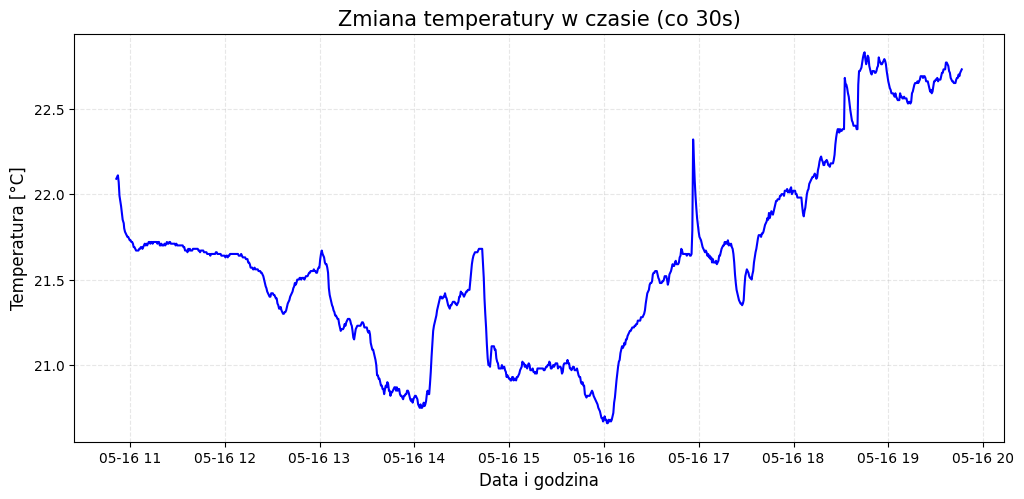

In [17]:
df['temperature'].plot(figsize = (12, 6), color = 'blue')

plt.title('Zmiana temperatury w czasie (co 30s)', fontsize = 15)
plt.xlabel('Data i godzina', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center')
plt.ylabel('Temperatura [°C]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

### Analiza przebiegu temperatury
1. **Anomalie i zdarzenia nagłe:**
   * Na wykresie wyraźnie widoczna jest pojedyncza anomalia w okolicach godziny 17:00, gdzie temperatura w bardzo krótkim czasie wzrosła o ok. 1°C, a następnie natychmiast spadła. Może to być spowodowane dotknięciem czujnika dłonią, dmuchnięciem ciepłym powietrzem lub po prostu chwilowym błędem oczytu danych.
2. **Gwałtowny wzrost temperatury w godzinach 17:00 - 19:00:**
   * W tych godzinach zaobserwowałem dynamiczny, liniowy wzrost temperatury z ok. 21.4°C do maksimum: 22.83°C. Taka zmiana w warunkach domowych zazwyczaj oznacza włączenie ogrzewania
3. **Wychładzanie:**
   * W pierwszej połowie dnia widoczny jest spadek temperatury, co sugeruje dopływy chłodniejszego powietrza do pomieszczenia. Szczególnie widać to w godzinach od 13:30 do 14:00 oraz 14:30 do 16:00 gdzie temperatura spada poniżej 21°C.

**Godzina i wartość wystąpienia najmniejszej temperatury:**

In [18]:
min_temp_val = df['temperature'].min()
min_temp_time = df['temperature'].idxmin()

f"Min: {min_temp_val}°C o godzinie: {min_temp_time}"

'Min: 20.66°C o godzinie: 2026-05-16 16:01:55'

**Godzina i wartosć wystąpienia największej temperatury:**

In [19]:
max_temp_val = df['temperature'].max()
max_temp_time = df['temperature'].idxmax()

f"Max: {max_temp_val}°C o godzinie: {max_temp_time}"

'Max: 22.83°C o godzinie: 2026-05-16 18:44:55'

## 12. Wykrycie i izolacja anomalii temperatury

#### Na wykresie wyżej zaobserwowałem bardzo wyraźną anomalię tuż przed godzina 17:00, gdzie temperatura nagle wzrosła, a następnie zmalała. Wyświetle dane o tym czasie, w którym mogło to wystąpić:

In [20]:
fragment_anomali = df.loc['2026-05-16 16:52:00':'2026-05-16 17:00:00']
fragment_anomali

,station_id,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0
timestamp,,,,,,,
2026-05-16 16:52:25,station_01,21.64,952.059141,522.3852,6,7,7
2026-05-16 16:52:56,station_01,21.65,952.017500,522.7501,6,7,8
2026-05-16 16:53:25,station_01,21.65,952.006875,522.8431,6,7,7
2026-05-16 16:53:55,station_01,21.65,952.017500,522.7966,6,8,8
2026-05-16 16:54:25,station_01,21.64,952.034219,522.6036,5,7,7
2026-05-16 16:54:55,station_01,21.64,952.014688,522.7744,6,8,9
2026-05-16 16:55:25,station_01,21.65,952.022109,522.7099,5,7,8
2026-05-16 16:55:55,station_01,21.79,952.042656,522.5295,4,7,8
2026-05-16 16:56:25,station_01,22.32,951.962188,523.2345,6,9,9


In [21]:
fragment_anomali['skok_temp'] = fragment_anomali['temperature'].diff()
fragment_anomali

,station_id,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0,skok_temp
timestamp,,,,,,,,
2026-05-16 16:52:25,station_01,21.64,952.059141,522.3852,6,7,7,NaN
2026-05-16 16:52:56,station_01,21.65,952.017500,522.7501,6,7,8,0.01
2026-05-16 16:53:25,station_01,21.65,952.006875,522.8431,6,7,7,0.00
2026-05-16 16:53:55,station_01,21.65,952.017500,522.7966,6,8,8,0.00
2026-05-16 16:54:25,station_01,21.64,952.034219,522.6036,5,7,7,-0.01
2026-05-16 16:54:55,station_01,21.64,952.014688,522.7744,6,8,9,0.00
2026-05-16 16:55:25,station_01,21.65,952.022109,522.7099,5,7,8,0.01
2026-05-16 16:55:55,station_01,21.79,952.042656,522.5295,4,7,8,0.14
2026-05-16 16:56:25,station_01,22.32,951.962188,523.2345,6,9,9,0.53


### Wnioski z analizy anomalii temperatury:
1. **Lokalizacja anomalii:** Jak można zauważyć, że największy nagły skok temperatury miał dokładnie miejsce o godzinie 16:56:25 a różnica wynosiła aż 0.53°C.
2. **Możliwa przyczyna:** Najrozsądniejszym wytłumaczniem tego zjawiska będzie to, że ktoś podszedł do czujnika i w niego chuchnął.
3. **Wpływ na dane:** Zdarzenie to nie zaburza ogólnego, długoterminowego trendu, więc nie ma potrzeby usuwania tego wiersza, a jedynie odnotowania, że coś takiego wystąpiło.

## 13. Wykres linii dla ciśnienia

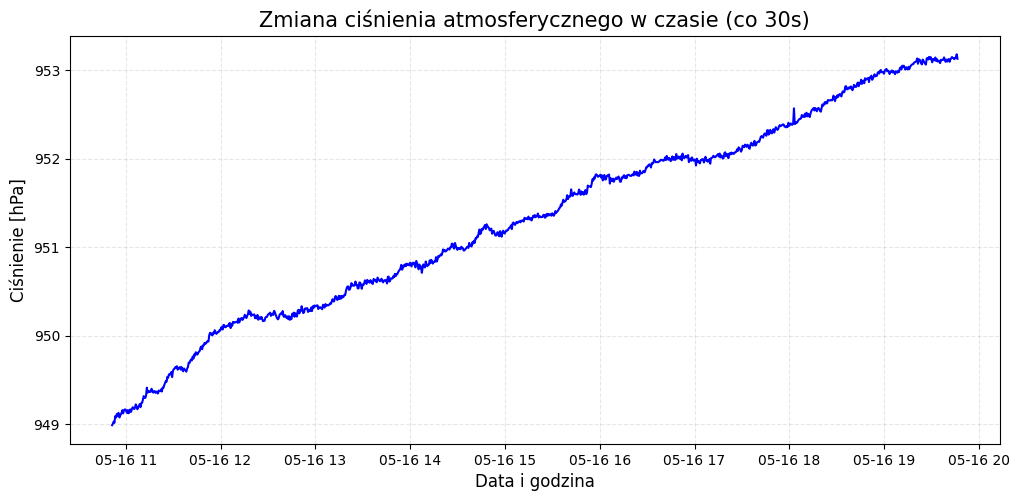

In [22]:
df['pressure'].plot(figsize = (12, 6), color = 'blue')

plt.title('Zmiana ciśnienia atmosferycznego w czasie (co 30s)', fontsize = 15)
plt.xlabel('Data i godzina', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center')
plt.ylabel('Ciśnienie [hPa]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

### Analiza przebiegu ciśnienia atmosferycznego
1. **Stabilny wzrost ciśnienia:**
   * Na wykresie wyraźnie widoczny jest jednostajny trend wzrostowy na przestrzeni całego dnia. Świadczy to o wkraczaniu w rejon pomiaru stabilnego układu wysokiego ciśnienia
2. **Brak wpływu mikroklimatu:**
   * W przeciwieństwie do temperatury, na tym wykresie nie widać żadnych wahań związanych z klimatem pomieszczenia, co potwierdza że ciśnienie w pomieszczeniach jest zawsze takie samo jak na zewnątrz.

#### Godzina i wartość wystąpienia najmniejszego ciśnienia:

In [23]:
min_press_val = df['pressure'].min()
min_press_time = df['pressure'].idxmin()

f"Min: {min_press_val} hPa o godzinie: {min_press_time}"

'Min: 948.9857812 hPa o godzinie: 2026-05-16 10:51:22'

#### Godzina i wartość wystąpienia największego ciśnienia:

In [24]:
max_press_val = df['pressure'].max()
max_press_time = df['pressure'].idxmax()

f"Max: {max_press_val} hPa o godzinie: {max_press_time}"

'Max: 953.1833594 hPa o godzinie: 2026-05-16 19:45:55'

## 14. Wygładzenie danych
#### Przez to, że czujnik generuje drobne, losowe wahania (szum), nałoże na wykres temperatury i ciśnienia średnią kroczącą (rolling average). Pozwoli nam to ukryć te szumy aby pokazać gładki trend zmian.

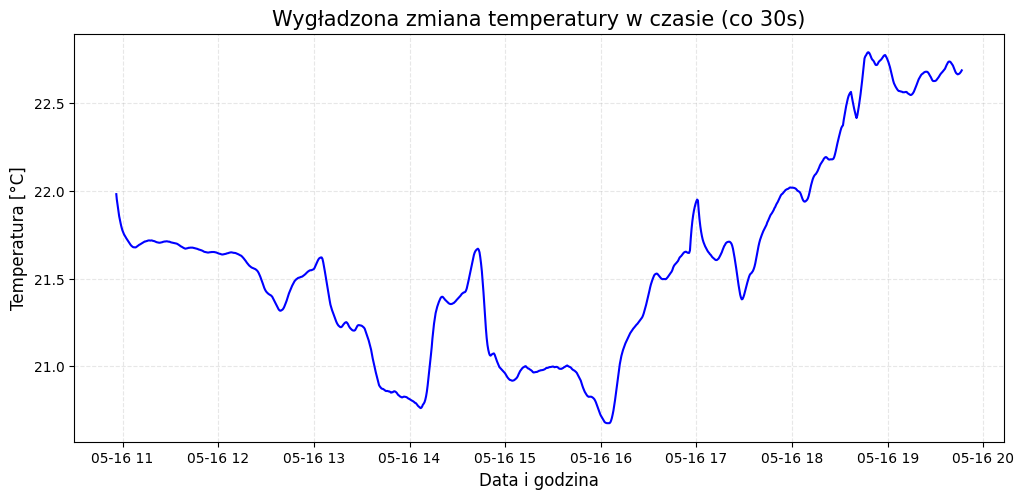

In [25]:
df['temp_rolling'] = df['temperature'].rolling(window = 10).mean()

df['temp_rolling'].plot(figsize = (12, 6), color = 'blue')

plt.title('Wygładzona zmiana temperatury w czasie (co 30s)', fontsize = 15)
plt.xlabel('Data i godzina', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center')
plt.ylabel('Temperatura [°C]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

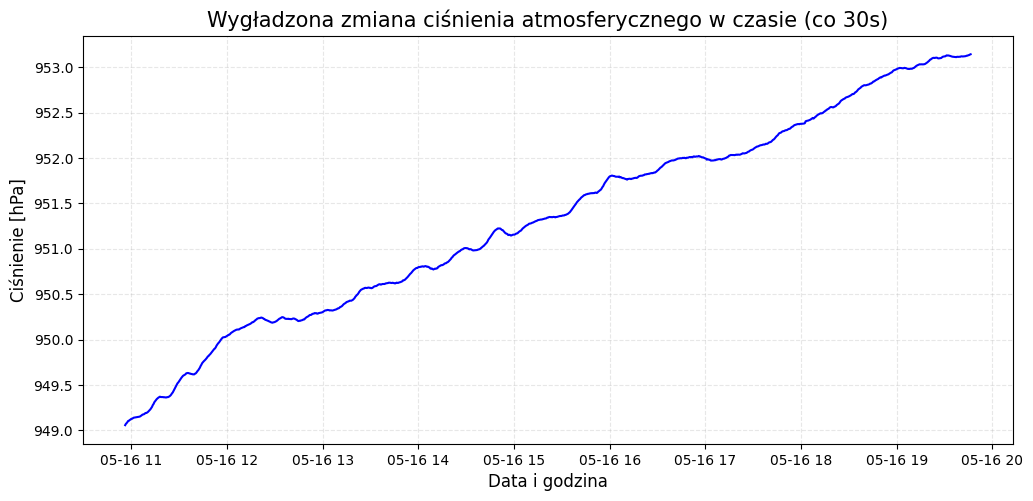

In [26]:
df['press_rolling'] = df['pressure'].rolling(window = 10).mean()

df['press_rolling'].plot(figsize = (12, 6), color = 'blue')

plt.title('Wygładzona zmiana ciśnienia atmosferycznego w czasie (co 30s)', fontsize = 15)
plt.xlabel('Data i godzina', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center')
plt.ylabel('Ciśnienie [hPa]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)

plt.show()